# 2-A. 제주 수요 장지평 — 풀드 직접 다지평 LGBM (1~168h)

> 2-0 EDA(G-9) 후속. 사용자 확정(Decision Gate):
> **구조 = LGBM 단독 / 풀드 직접(direct) 다지평** (재귀 rolling 아님) / **기상 = 기온·습도·일사·풍속**(제주 3지점 평균).
> 기존 PatchTST+LGBM **D+1** 파이프라인(`demand_predict.py`)은 그대로 둔다 — 본 노트북은 장지평 신규 모델.
>
> ## 설계 핵심 (누수 없음)
> 원점 T(=하루 끝 23:00 실측)에서 T+h (h=1..168) 를 **한 모델로 직접** 예측. 입력은
> 모두 원점에서 알 수 있거나(과거 lag·최근레벨) 결정적(달력)이거나 예보로 주어지는(기상) 값:
> - **lag168** = T+h−168 의 실측 (h≤168 이면 전 구간 ≤T → 항상 가용, 주간 신호. 모델의 척추)
> - **최근레벨** = 원점까지 직전 24h·168h 평균 (원점에서 알려진 수준)
> - **기상**(기온/습도/일사/풍속, 제주평균) at T+h — 학습/평가는 실측 기상 = 완전기상 상한선
> - **달력** hour/dow/month sin·cos + **day_type** (결정값) + **지평 h**
> - **구름**(total_cloud·midlow_cloud, **west·south 2지점 raw** — 평균 안 냄) — **h≤48(D+1/D+2)만** 투입, 그 외 NaN.
>   일사 발전 지점(west·south)의 구름이 BTM 태양광과 직접 관련 + forecast에 구름이 west·south만 존재(east 없음→서빙 정합).
>   구름예보 신뢰도가 단지평만 유효 / 2-0b: 낮시간 잔차↔구름 +0.37. 장지평은 LGBM 네이티브 NaN 처리.
> - **BTM/PPA 용량**(`cap_btmppa_mw`, 월별 비계량 태양광 용량, 전력거래소) — 비계량 태양광이
>   계통수요를 끌어내리는 레벨을 모델이 앵커링(2-0b 검증). 전 지평 가용(월별 결정값).
> - **흐린날 특화(순수 기상, BTM 추정 아님)**: `solar_deficit`=clip(1−일사/평년일사) · `solar_ramp`=|Δ일사|, h≤48만.
>   흐린날 계통수요 surge(KPX 과소예측) 직접 신호화(2-0c).
> - **비대칭 손실(quantile α=0.60) + 낮시간(08~16h) 가중2** — 흐린날 과소예측 편향 제거(낮시간 정확도 1순위).
> - land 5-A 대비: lag24 제거, h 유지, month 포함. (2-0b/2-0c 후속 채택 — 사용자 Decision Gate)
>
> 학습창 train(타깃 ≤2025-02) / val(~2026-03-21) / test(2026-03-22~05-31) — 기존 제주 2단계와 동일.
> 베이스라인 = KPX `jeju_est_demand_da`(하루전) + naive lag168 + PatchTST(D+1 비교).

In [1]:
import os, sqlite3, json, warnings
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family']='Malgun Gothic'; mpl.rcParams['axes.unicode_minus']=False; mpl.rcParams['figure.dpi']=110
HERE=os.getcwd()
FIG=os.path.join(HERE,'fig'); os.makedirs(FIG,exist_ok=True)
TAB=os.path.join(HERE,'tab'); os.makedirs(TAB,exist_ok=True)
MODELS=os.path.join(HERE,'models'); os.makedirs(MODELS,exist_ok=True)
DB=os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','data','input_data_jeju.db'))
STATIONS=['west','east','south']; SOLAR_ST=['west','south']
WX=['temp_c','humidity','solar_rad','wind_spd']   # 사용자 확정 기상 4종(3지점 평균/일사 2지점)
CLOUD=['total_cloud_west','total_cloud_south','midlow_cloud_west','midlow_cloud_south']  # west·south raw 2지점(평균 안 냄)
CAP_CSV=os.path.normpath(os.path.join(HERE,'..','data','jeju_ppa_btm_capacity_mw.csv'))
pull=['timestamp','real_demand_jeju','jeju_est_demand_da','day_type','real_solar_utilization_jeju']
for st in STATIONS:
    for w in ['temp_c','humidity','wind_spd']: pull.append(f'{w}_{st}')
for st in SOLAR_ST: pull.append(f'solar_rad_{st}')
pull+=CLOUD
con=sqlite3.connect(DB)
raw=pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp'])
# patchtst 신호(D+1 비교용)
ptst=pd.read_sql('SELECT timestamp, jeju_patchtst_target FROM patchtst_signal', con, parse_dates=['timestamp'])
# forecast 기상(실서빙 낮시간 평가용)
FCQ="SELECT timestamp, temp_west,temp_south, reh_west,reh_south, wind_spd_10m_west,wind_spd_10m_south, radiation_west,radiation_south, total_cloud_west,total_cloud_south, midlow_cloud_west,midlow_cloud_south FROM forecast"
fcw=pd.read_sql(FCQ, con, parse_dates=['timestamp'])
con.close()
raw=raw.sort_values('timestamp').reset_index(drop=True)
raw['temp_c']   = raw[[f'temp_c_{st}'   for st in STATIONS]].mean(axis=1)
raw['humidity'] = raw[[f'humidity_{st}' for st in STATIONS]].mean(axis=1)
raw['wind_spd'] = raw[[f'wind_spd_{st}' for st in STATIONS]].mean(axis=1)
raw['solar_rad']= raw[[f'solar_rad_{st}' for st in SOLAR_ST]].mean(axis=1)
raw=raw.merge(ptst, on='timestamp', how='left')
raw=raw[['timestamp','real_demand_jeju','jeju_est_demand_da','day_type','jeju_patchtst_target','real_solar_utilization_jeju']+WX+CLOUD]
print(raw.shape, raw.timestamp.min(),'~',raw.timestamp.max())

(56352, 14) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


## 1. 연속 시간축 정렬 + 결측 보간

시간 구멍이 있으면 lag 인덱싱이 깨진다 → 전체 시간축으로 reindex 후 보간(타깃 0/NaN→시간보간, dropna 금지).

In [2]:
full_idx=pd.date_range(raw.timestamp.min(), raw.timestamp.max(), freq='h')
d=raw.set_index('timestamp').reindex(full_idx); d.index.name='timestamp'
n_zero=int((d.real_demand_jeju==0).sum()); n_nan=int(d.real_demand_jeju.isna().sum())
d.loc[d.real_demand_jeju==0,'real_demand_jeju']=np.nan
d['real_demand_jeju']=d['real_demand_jeju'].interpolate(method='time')
for w in WX+CLOUD+['real_solar_utilization_jeju']: d[w]=d[w].interpolate(method='time')
d['day_type']=d['day_type'].ffill().bfill()
# BTM/PPA 용량 병합 (월별 결정값) — 비계량 태양광 레벨 앵커
cap=pd.read_csv(CAP_CSV)
d['year']=d.index.year; d['month_']=d.index.month
d=d.reset_index().merge(cap,left_on=['year','month_'],right_on=['year','month'],how='left').set_index('timestamp')
d=d.drop(columns=['year','month_','month'])
print(f'reindex {len(raw)}->{len(d)} (구멍 {len(d)-len(raw)}h)  타깃 0={n_zero} NaN={n_nan} 보간완료')
print('남은 타깃 NaN:', int(d.real_demand_jeju.isna().sum()), ' cap NaN:', int(d.cap_btmppa_mw.isna().sum()))

reindex 56352->56352 (구멍 0h)  타깃 0=5 NaN=10 보간완료
남은 타깃 NaN: 0  cap NaN: 0


## 2. 직접 다지평 샘플 구성 (origin × h)

origin = 매일 23:00 (하루 끝, 하루전 발행 가정). 각 origin 에서 h=1..168 의 타깃과 누수 없는 피처 생성.

In [3]:
dem=d.real_demand_jeju.values.astype(float)
base=d.jeju_est_demand_da.values.astype(float)
ptst_arr=d.jeju_patchtst_target.values.astype(float)
temp=d.temp_c.values; hum=d.humidity.values; solar=d.solar_rad.values; wind=d.wind_spd.values
cloud_arr={c:d[c].values for c in CLOUD}; cap_arr=d.cap_btmppa_mw.values
hour=d.index.hour.values; dow=d.index.dayofweek.values; month=d.index.month.values
dtype_arr=d.day_type.values.astype(object)
N=len(d)
# 흐린날 특화(순수 기상): 평년(월,시) 대비 일사결손비율 + 일사램프 (train 평년)
trmask=(d.index<='2025-02-28 23:00')
cs=pd.Series(np.where(trmask,solar,np.nan)).groupby([month,hour]).transform('mean').values
clim_solar=pd.Series(solar).groupby([month,hour]).transform('mean').values  # 전체 평년(폴백)
clim_solar=np.where(np.isfinite(cs),cs,clim_solar)
with np.errstate(divide='ignore',invalid='ignore'):
    solar_deficit=np.where(clim_solar>5, np.clip(1-solar/clim_solar,-0.5,1.5), 0.0)
solar_ramp=np.abs(np.diff(solar,prepend=np.nan))
rec24 =pd.Series(dem).rolling(24, min_periods=24).mean().values
rec168=pd.Series(dem).rolling(168,min_periods=168).mean().values
H=np.arange(1,169)
origins=np.where((hour==23)&(np.arange(N)>=167)&(np.arange(N)<=N-1-168))[0]
P=origins
tgt=(P[:,None]+H[None,:]).ravel()
hh =np.broadcast_to(H,(len(P),168)).ravel()
def col(a): return a[tgt]
samp=pd.DataFrame({
 'y':col(dem),
 'h':hh.astype(np.int16),
 'lag168':dem[tgt-168],
 'rec24':np.repeat(rec24[P],168),
 'rec168':np.repeat(rec168[P],168),
 'temp_c':col(temp),'humidity':col(hum),'solar_rad':col(solar),'wind_spd':col(wind),
 'cap_btmppa_mw':col(cap_arr),
 'hour':col(hour),'dow':col(dow),'month':col(month),
 'day_type':col(dtype_arr),
 'base':col(base),'ptst':col(ptst_arr),
 'util':col(d.real_solar_utilization_jeju.values),
 'tts':d.index.values[tgt],
})
# 구름·흐린날피처: h≤48(D+1/D+2)만 투입 그 외 NaN
for c in CLOUD: samp[c]=np.where(samp.h<=48, col(cloud_arr[c]), np.nan)
samp['solar_deficit']=np.where(samp.h<=48, col(solar_deficit), np.nan)
samp['solar_ramp']=np.where(samp.h<=48, col(solar_ramp), np.nan)
samp['hour_sin']=np.sin(2*np.pi*samp.hour/24); samp['hour_cos']=np.cos(2*np.pi*samp.hour/24)
samp['dow_sin'] =np.sin(2*np.pi*samp.dow/7);   samp['dow_cos'] =np.cos(2*np.pi*samp.dow/7)
samp['month_sin']=np.sin(2*np.pi*samp.month/12);samp['month_cos']=np.cos(2*np.pi*samp.month/12)
samp=samp[samp.y.notna() & samp.lag168.notna()].reset_index(drop=True)
samp['day_type']=samp['day_type'].astype('category')
print('origins:',len(P),' 샘플행:',len(samp))

origins: 2335  샘플행: 392280


## 3. 분할 + LGBM 학습

타깃 시각 기준 train ≤2025-02-28 / val 2025-03-01~2026-03-21 / test 2026-03-22~2026-05-31 (기존 제주 2단계와 동일).

In [4]:
FEAT=['h','lag168','rec24','rec168','temp_c','humidity','solar_rad','wind_spd',
      'total_cloud_west','total_cloud_south','midlow_cloud_west','midlow_cloud_south',
      'cap_btmppa_mw','solar_deficit','solar_ramp',
      'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos','day_type']
CAT=['day_type']
samp['is_day']=((samp.hour>=8)&(samp.hour<=16)).astype(int)
tts=pd.to_datetime(samp.tts)
tr=samp[tts<='2025-02-28 23:00']
va=samp[(tts>='2025-03-01')&(tts<='2026-03-21 23:00')]
te=samp[(tts>='2026-03-22')&(tts<='2026-05-31 23:00')]
print('train',tr.shape,'val',va.shape,'test',te.shape)
# 비대칭 손실(quantile α=0.60) + 낮시간(08~16h) 가중2 — 흐린날 surge 과소예측 공략(사용자 확정)
ALPHA=0.60; DAY_W=2.0
wtr=np.where(tr.is_day.values==1,DAY_W,1.0); wva=np.where(va.is_day.values==1,DAY_W,1.0)
dtr=lgb.Dataset(tr[FEAT],tr.y,weight=wtr,categorical_feature=CAT)
dva=lgb.Dataset(va[FEAT],va.y,weight=wva,categorical_feature=CAT,reference=dtr)
params=dict(objective='quantile',alpha=ALPHA,metric='quantile',learning_rate=0.024,num_leaves=244,
            min_data_in_leaf=76,feature_fraction=0.9,bagging_fraction=0.8,bagging_freq=5,
            lambda_l2=0.1,verbosity=-1,random_state=42)
model=lgb.train(params,dtr,num_boost_round=4000,valid_sets=[dva],valid_names=['val'],
                callbacks=[lgb.early_stopping(150),lgb.log_evaluation(300)])
best=int(model.best_iteration); print('best_iter',best,'val pinball',round(model.best_score['val']['quantile'],3))

train (315168, 31) val (64848, 31) test (11904, 31)


Training until validation scores don't improve for 150 rounds


Early stopping, best iteration is:
[149]	val's quantile: 15.9592
best_iter 149 val pinball 15.959


## 4. 지평별 정확도 (정직성 2겹: 완전기상 상한선 ↔ 기후값 하한선)

평가는 **D+1~D+7(각 24시간 전체)** 단위. 24의 배수 h 만 보면 23시 한 시각만 평가돼 낙관편향 →
day-ahead 블록(h를 24로 묶어 전 시각 포함)으로 집계.
- 완전기상(perfect): 실측 기상 = 상한선. 기후값(climatology): (월,시) 기후평균 = 하한선. 운영은 그 사이.
- 비교선: KPX 하루전 `jeju_est_demand_da`, naive lag168.

 dayahead  perfect  climatology  naive168  kpx    n
        1     3.82         6.84      8.80 5.94 1680
        2     3.88         6.85      8.75 6.01 1704
        3     4.00         6.88      8.75 6.01 1704
        4     4.03         6.91      8.75 6.01 1704
        5     4.07         6.92      8.75 6.01 1704
        6     4.05         6.92      8.75 6.01 1704
        7     4.10         6.94      8.75 6.01 1704

전체 test MAPE  perfect=3.99%  climatology=6.90%  naive168=8.76%  KPX=6.00%


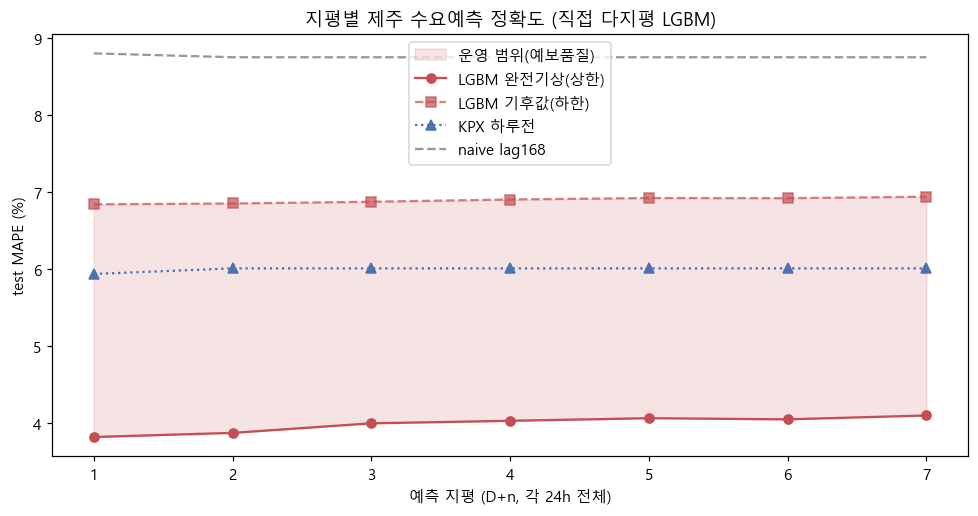

In [5]:
def mape(a,p):
    a=np.asarray(a,float); p=np.asarray(p,float); m=(a>0)&np.isfinite(a)&np.isfinite(p)
    return float(np.mean(np.abs(a[m]-p[m])/a[m])*100)
te=te.copy(); te['pred']=model.predict(te[FEAT],num_iteration=best)
clim={}; trm=samp[pd.to_datetime(samp.tts)<='2025-02-28 23:00']
H48=['total_cloud_west','total_cloud_south','midlow_cloud_west','midlow_cloud_south','solar_deficit','solar_ramp']
for w in WX+H48: clim[w]=trm.groupby([trm.month,trm.hour])[w].mean()
te_c=te.copy()
for w in WX: te_c[w]=[clim[w].get((mo,ho),np.nan) for mo,ho in zip(te_c.month,te_c.hour)]
# 구름·흐린날피처도 기후값(하한)으로 — h≤48 마스킹 유지. 용량(cap)은 결정값이라 실측 유지.
for w in H48:
    te_c[w]=[clim[w].get((mo,ho),np.nan) if hh_<=48 else np.nan
             for mo,ho,hh_ in zip(te_c.month,te_c.hour,te_c.h)]
te['pred_clim']=model.predict(te_c[FEAT],num_iteration=best)
te['dayahead']=((te.h-1)//24+1).astype(int)
rows=[]
for dn,g in te.groupby('dayahead'):
    rows.append(dict(dayahead=int(dn), perfect=mape(g.y,g.pred), climatology=mape(g.y,g.pred_clim),
                     naive168=mape(g.y,g.lag168), kpx=mape(g.y,g.base), n=len(g)))
da=pd.DataFrame(rows); da.to_csv(os.path.join(TAB,'2-A_mape_by_dayahead.csv'),index=False)
print(da.round(2).to_string(index=False))
print('\n전체 test MAPE  perfect=%.2f%%  climatology=%.2f%%  naive168=%.2f%%  KPX=%.2f%%'
      %(mape(te.y,te.pred),mape(te.y,te.pred_clim),mape(te.y,te.lag168),mape(te.y,te.base)))
hz=pd.DataFrame([dict(h=int(h),perfect=mape(g.y,g.pred),climatology=mape(g.y,g.pred_clim)) for h,g in te.groupby('h')])
hz.to_csv(os.path.join(TAB,'2-A_mape_by_horizon.csv'),index=False)
fig,ax=plt.subplots(figsize=(9,4.8))
x=da.dayahead
ax.fill_between(x, da.perfect, da.climatology, color='#C44E52', alpha=.15, label='운영 범위(예보품질)')
ax.plot(x, da.perfect, 'o-', color='#C44E52', label='LGBM 완전기상(상한)')
ax.plot(x, da.climatology, 's--', color='#C44E52', alpha=.7, label='LGBM 기후값(하한)')
ax.plot(x, da.kpx, '^:', color='#4C72B0', label='KPX 하루전')
ax.plot(x, da.naive168, color='#999', ls='--', label='naive lag168')
ax.set_xlabel('예측 지평 (D+n, 각 24h 전체)'); ax.set_ylabel('test MAPE (%)')
ax.set_xticks(x); ax.set_title('지평별 제주 수요예측 정확도 (직접 다지평 LGBM)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-A_mape_horizon.png'),bbox_inches='tight'); plt.show()

## 5. D+1(24h) PatchTST 비교 (사용자 요청)

기존 제주 D+1 의 핵심 신호였던 PatchTST(`jeju_patchtst_target`) 와, 신규 직접 다지평 LGBM 의 D+1 블록을
동일 test 구간에서 비교. KPX 하루전도 함께. (※ 신규 LGBM 은 PatchTST 신호를 쓰지 않는다 — 순수 비교)

In [6]:
d1=te[te.dayahead==1]
print('=== D+1 (24h 블록) test 정확도 ===')
print('  신규 LGBM 직접(완전기상) : MAPE %.2f%%' % mape(d1.y, d1.pred))
print('  신규 LGBM 직접(기후값)   : MAPE %.2f%%' % mape(d1.y, d1.pred_clim))
print('  PatchTST 신호(단독)      : MAPE %.2f%%  (NaN %d/%d)'
      % (mape(d1.y, d1.ptst), int(d1.ptst.isna().sum()), len(d1)))
print('  KPX 하루전               : MAPE %.2f%%' % mape(d1.y, d1.base))
print('  naive lag168             : MAPE %.2f%%' % mape(d1.y, d1.lag168))
cmp=pd.DataFrame([
  dict(model='LGBM직접(완전기상)', mape=round(mape(d1.y,d1.pred),3)),
  dict(model='LGBM직접(기후값)',   mape=round(mape(d1.y,d1.pred_clim),3)),
  dict(model='PatchTST단독',       mape=round(mape(d1.y,d1.ptst),3)),
  dict(model='KPX하루전',          mape=round(mape(d1.y,d1.base),3)),
  dict(model='naive_lag168',       mape=round(mape(d1.y,d1.lag168),3)),
])
cmp.to_csv(os.path.join(TAB,'2-A_d1_compare.csv'),index=False)
print('\n(참고) 배포된 PatchTST+LGBM D+1 모델 자체 평가 test MAPE ≈ 3.98% — 단, test 구간/집계 단위 상이.')

=== D+1 (24h 블록) test 정확도 ===
  신규 LGBM 직접(완전기상) : MAPE 3.82%
  신규 LGBM 직접(기후값)   : MAPE 6.84%
  PatchTST 신호(단독)      : MAPE 6.06%  (NaN 0/1680)
  KPX 하루전               : MAPE 5.94%
  naive lag168             : MAPE 8.80%

(참고) 배포된 PatchTST+LGBM D+1 모델 자체 평가 test MAPE ≈ 3.98% — 단, test 구간/집계 단위 상이.


## 5b. 낮시간(08~16h) 정확도 — 완전기상 vs forecast기상, 흐림/맑음 (★ 1순위 지표)

KPX `est_demand_da` 의 약점 = 낮시간 BTM 변동(특히 흐린 날) 미반영. 본 모델이 거기서 우위인지 본다.
- 흐림/맑음 = test 낮시간 태양광이용률 하위/상위 25%.
- 완전기상(실측, 상한) / forecast기상(실서빙). 평가지표=낮시간 MAPE.

낮시간(08~16h) MAPE  (흐림/맑음=낮 이용률 하위/상위25%)
          src  낮전체  낮흐림  낮맑음   전체
          KPX 9.09 6.90 9.94 6.00
      모델 완전기상 6.16 5.60 6.29 3.99
모델 forecast기상 8.04 6.87 8.94 4.80


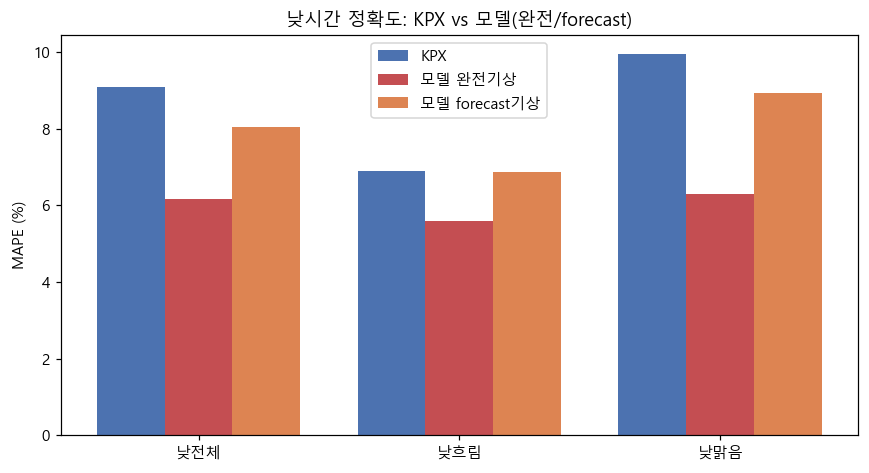

In [7]:
# forecast 기상 정렬(실서빙 평가)
FW=pd.DataFrame(index=d.index)
FW['temp_c']=fcw.set_index('timestamp')[['temp_west','temp_south']].mean(axis=1).reindex(d.index)
FW['humidity']=fcw.set_index('timestamp')[['reh_west','reh_south']].mean(axis=1).reindex(d.index)
FW['wind_spd']=fcw.set_index('timestamp')[['wind_spd_10m_west','wind_spd_10m_south']].mean(axis=1).reindex(d.index)
FW['solar_rad']=fcw.set_index('timestamp')[['radiation_west','radiation_south']].mean(axis=1).reindex(d.index)
for c in CLOUD: FW[c]=fcw.set_index('timestamp')[c].reindex(d.index)
with np.errstate(divide='ignore',invalid='ignore'):
    fdef=np.where(clim_solar>5,np.clip(1-FW.solar_rad.values/clim_solar,-0.5,1.5),0.0)
framp=np.abs(np.diff(FW.solar_rad.values,prepend=np.nan))
fdef_s=pd.Series(fdef,index=d.index); framp_s=pd.Series(framp,index=d.index)
ttv=pd.to_datetime(te.tts)
te_fc=te.copy()
for c in ['temp_c','humidity','solar_rad','wind_spd']: te_fc[c]=FW[c].reindex(ttv).values
for c in CLOUD: te_fc[c]=np.where(te_fc.h<=48, FW[c].reindex(ttv).values, np.nan)
te_fc['solar_deficit']=np.where(te_fc.h<=48, fdef_s.reindex(ttv).values, np.nan)
te_fc['solar_ramp']=np.where(te_fc.h<=48, framp_s.reindex(ttv).values, np.nan)
te_fc['pred']=model.predict(te_fc[FEAT],num_iteration=best)
# 낮시간 평가
dmask=(te.hour>=8)&(te.hour<=16)
dq=te[dmask].copy(); dq['uq']=pd.qcut(dq.util,4,labels=False,duplicates='drop')
cidx=dq[dq.uq==0].index; ridx=dq[dq.uq==3].index   # 흐림/맑음 인덱스(완전·forecast 공통)
def dl(df,idxs): g=df.loc[idxs]; return mape(g.y,g.pred)
rows2=[]
rows2.append(dict(src='KPX', 낮전체=mape(te[dmask].y,te[dmask].base),
                  낮흐림=mape(te.loc[cidx].y,te.loc[cidx].base), 낮맑음=mape(te.loc[ridx].y,te.loc[ridx].base),
                  전체=mape(te.y,te.base)))
rows2.append(dict(src='모델 완전기상', 낮전체=mape(te[dmask].y,te[dmask].pred),
                  낮흐림=dl(te,cidx), 낮맑음=dl(te,ridx), 전체=mape(te.y,te.pred)))
rows2.append(dict(src='모델 forecast기상', 낮전체=mape(te_fc[dmask].y,te_fc[dmask].pred),
                  낮흐림=dl(te_fc,cidx), 낮맑음=dl(te_fc,ridx), 전체=mape(te_fc.y,te_fc.pred)))
dayt=pd.DataFrame(rows2); dayt.to_csv(os.path.join(TAB,'2-A_daytime.csv'),index=False)
print('낮시간(08~16h) MAPE  (흐림/맑음=낮 이용률 하위/상위25%)')
print(dayt.round(2).to_string(index=False))
fig,ax=plt.subplots(figsize=(8,4.4))
xl=['낮전체','낮흐림','낮맑음']; xx=np.arange(3); wd=0.26
ax.bar(xx-wd,[dayt.iloc[0][c] for c in xl],wd,label='KPX',color='#4C72B0')
ax.bar(xx,   [dayt.iloc[1][c] for c in xl],wd,label='모델 완전기상',color='#C44E52')
ax.bar(xx+wd,[dayt.iloc[2][c] for c in xl],wd,label='모델 forecast기상',color='#DD8452')
ax.set_xticks(xx); ax.set_xticklabels(xl); ax.set_ylabel('MAPE (%)')
ax.set_title('낮시간 정확도: KPX vs 모델(완전/forecast)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-A_daytime.png'),bbox_inches='tight'); plt.show()

## 6. 피처 중요도 + 예시 168h 예측

           feature         gain  split  gain_pct
            lag168 1.577578e+06   2276      40.6
            temp_c 5.846657e+05   6016      15.0
          hour_sin 2.896259e+05   3015       7.5
         solar_rad 2.803984e+05   4061       7.2
     cap_btmppa_mw 2.044562e+05   4373       5.3
          humidity 1.971639e+05   3433       5.1
             rec24 1.534027e+05    925       3.9
          hour_cos 1.396862e+05   1834       3.6
          day_type 1.291565e+05   1853       3.3
            rec168 8.276091e+04   1787       2.1
         month_sin 6.936314e+04   1677       1.8
          wind_spd 5.699006e+04   1747       1.5
         month_cos 5.444157e+04   1237       1.4
           dow_sin 3.350372e+04    952       0.9
           dow_cos 1.566832e+04    522       0.4
  total_cloud_west 7.398761e+03    195       0.2
 total_cloud_south 5.603924e+03    143       0.1
midlow_cloud_south 2.382531e+03     63       0.1
        solar_ramp 1.518886e+03     49       0.0
                 h 1

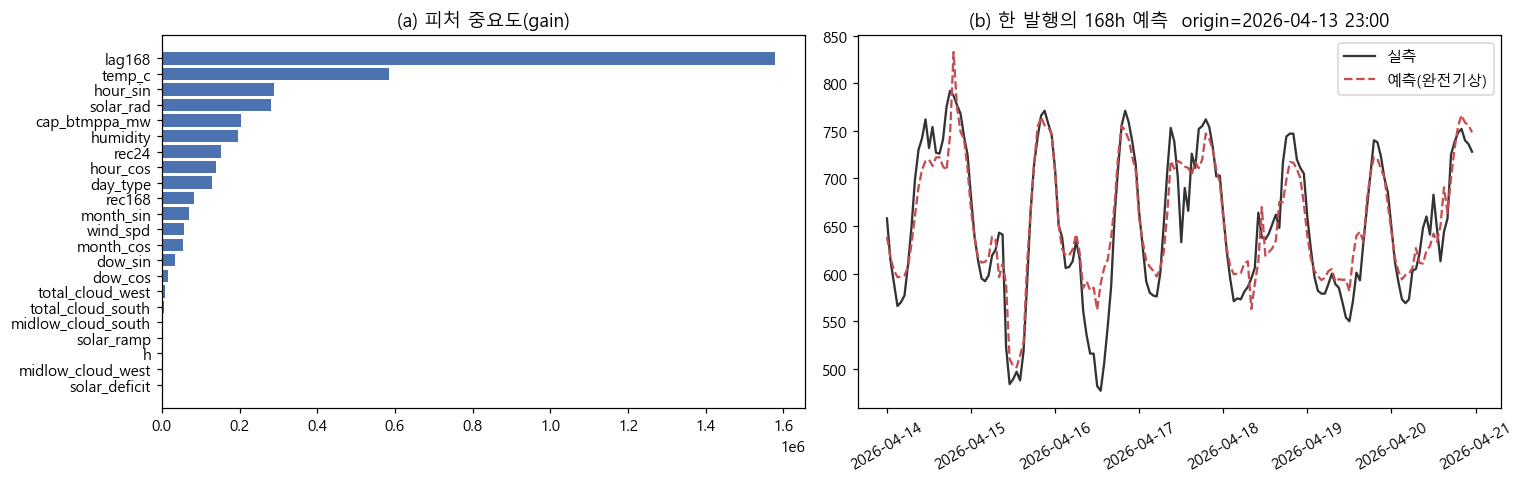

In [8]:
imp=pd.DataFrame({'feature':model.feature_name(),
    'gain':model.feature_importance('gain'),'split':model.feature_importance('split')}).sort_values('gain',ascending=False)
imp['gain_pct']=(imp.gain/imp.gain.sum()*100).round(1)
imp.to_csv(os.path.join(TAB,'2-A_importance.csv'),index=False)
print(imp.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(14,4.5))
ax[0].barh(imp.feature[::-1],imp.gain[::-1],color='#4C72B0'); ax[0].set_title('(a) 피처 중요도(gain)')
te['origin']=pd.to_datetime(te['tts']) - pd.to_timedelta(te['h'],unit='h')
ex=pd.to_datetime(te['origin']).dropna().unique()
ex_origin=pd.Timestamp('2026-04-13 23:00') if pd.Timestamp('2026-04-13 23:00') in set(pd.to_datetime(te.origin)) else pd.to_datetime(te.origin).min()
g=te[pd.to_datetime(te.origin)==ex_origin].sort_values('h')
ax[1].plot(pd.to_datetime(g.tts),g.y,label='실측',color='#333',lw=1.5)
ax[1].plot(pd.to_datetime(g.tts),g.pred,label='예측(완전기상)',color='#C44E52',lw=1.5,ls='--')
ax[1].set_title(f'(b) 한 발행의 168h 예측  origin={ex_origin:%Y-%m-%d %H:%M}'); ax[1].legend()
ax[1].tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-A_importance_example.png'),bbox_inches='tight'); plt.show()

## 7. 저장 + 보고서

In [9]:
model.save_model(os.path.join(MODELS,'lgbm_jeju_demand_direct.txt'),num_iteration=best)
meta=dict(features=FEAT,categorical=CAT,target='real_demand_jeju',best_iteration=best,
          horizon='1..168 direct (D+1~D+7)',origin_hour=23,
          weather=WX+['jeju 3-station spatial mean (solar 2-station)'],
          cloud=CLOUD, cloud_horizon_mask='h<=48 only (D+1/D+2), else NaN',
          cloudy_features=['solar_deficit (1-solar/clim_solar)','solar_ramp (|d solar|)','h<=48 only'],
          cap_feature='cap_btmppa_mw (monthly BTM+PPA solar capacity MW, 전력거래소; data/jeju_ppa_btm_capacity_mw.csv)',
          objective='quantile', alpha=0.60, daytime_weight=2.0, daytime_hours='08-16',
          serving_weather='raw forecast (QM 미적용 — QM은 흐린날 순효과 음, 2-0c 검증)',
          train='target<=2025-02-28',val='2025-03-01..2026-03-21',test='2026-03-22..2026-05-31',
          params=params,
          note='LGBM-only direct multi-horizon. h kept, lag24 dropped. +cloud(west/south raw,h<=48)+BTM/PPA capacity+흐린날피처(solar_deficit/ramp). '
               '비대칭 quantile(0.60)+낮가중2로 흐린날 surge 과소예측 공략(2-0c, 사용자 Decision Gate). '
               '예측은 ~0.60분위(의도적 상향=과소예측 회피). 기존 PatchTST+LGBM D+1 파이프라인은 별도 유지.')
json.dump(meta,open(os.path.join(MODELS,'model_meta_direct.json'),'w',encoding='utf-8'),ensure_ascii=False,indent=2)
def D(n,c): return float(da[da.dayahead==n][c].iloc[0])
rep=f'''# 2-A 보고서 — 제주 수요 장지평 직접 다지평 LGBM

## 구조 (사용자 확정 — Decision Gate)
- LGBM 단독, **풀드 직접(direct) 다지평** 1~168h(D+1~D+7) 단일모델. 재귀 아님.
- 피처 {len(FEAT)}개: h, lag168, rec24, rec168, 기상4(기온·습도·일사·풍속), **구름4(total/midlow_cloud west·south raw, h≤48)**,
  **cap_btmppa_mw(BTM/PPA 용량)**, **흐린날피처(solar_deficit·solar_ramp, h≤48)**, 달력(hour/dow/month sin·cos), day_type.
- **비대칭 손실 quantile(α=0.60) + 낮시간(08~16h) 가중2** — KPX가 못 잡는 흐린날 낮 surge 과소예측 공략(2-0c).
  예측은 ~0.60분위(의도적 상향). 구름은 east가 forecast에 없어 west·south raw. **서빙=raw forecast(QM 미적용)**.
- 학습창: train ≤2025-02 / val ~2026-03-21 / test 2026-03-22~05-31. best_iter={best}.
- 기존 PatchTST+LGBM **D+1** 파이프라인은 그대로 유지(별도 운영).

## 결과 (test) — MAPE %
| 지평 | 완전기상(상한) | 기후값(하한) | KPX 하루전 | naive lag168 |
|---|---|---|---|---|
| D+1 | {D(1,'perfect'):.2f} | {D(1,'climatology'):.2f} | {D(1,'kpx'):.2f} | {D(1,'naive168'):.2f} |
| D+2 | {D(2,'perfect'):.2f} | {D(2,'climatology'):.2f} | {D(2,'kpx'):.2f} | {D(2,'naive168'):.2f} |
| D+3 | {D(3,'perfect'):.2f} | {D(3,'climatology'):.2f} | {D(3,'kpx'):.2f} | {D(3,'naive168'):.2f} |
| D+7 | {D(7,'perfect'):.2f} | {D(7,'climatology'):.2f} | {D(7,'kpx'):.2f} | {D(7,'naive168'):.2f} |
| 전체 | {mape(te.y,te.pred):.2f} | {mape(te.y,te.pred_clim):.2f} | {mape(te.y,te.base):.2f} | {mape(te.y,te.lag168):.2f} |

## ★ 낮시간(08~16h) 정확도 — KPX가 못 잡는 흐린날 surge (1순위 지표, tab/2-A_daytime.csv)
| | 낮전체 | 낮흐림 | 낮맑음 | 전체 |
|---|---|---|---|---|
| KPX 하루전 | {dayt.iloc[0]['낮전체']:.2f} | {dayt.iloc[0]['낮흐림']:.2f} | {dayt.iloc[0]['낮맑음']:.2f} | {dayt.iloc[0]['전체']:.2f} |
| 모델 완전기상(상한) | {dayt.iloc[1]['낮전체']:.2f} | {dayt.iloc[1]['낮흐림']:.2f} | {dayt.iloc[1]['낮맑음']:.2f} | {dayt.iloc[1]['전체']:.2f} |
| 모델 forecast기상(실서빙) | {dayt.iloc[2]['낮전체']:.2f} | {dayt.iloc[2]['낮흐림']:.2f} | {dayt.iloc[2]['낮맑음']:.2f} | {dayt.iloc[2]['전체']:.2f} |
- 비대칭(quantile 0.60)+낮가중2+흐린날피처로 흐린날 surge 과소예측을 공략 → 완전기상에선 흐림·맑음 모두 KPX 압도.
- 실서빙(forecast)에선 맑음·낮전체는 KPX 우위 유지, 흐림은 예보(구름·일사) 품질 한계로 KPX와 비등(예보 본질 문제, 2-0c).
- QM(분포보정)은 흐린날 순효과 음이라 미적용. cape 등은 forecast 전용이라 미채택.

## D+1 PatchTST 비교 (tab/2-A_d1_compare.csv)
- 신규 LGBM 직접(완전기상) {mape(d1.y,d1.pred):.2f}% / (기후값) {mape(d1.y,d1.pred_clim):.2f}%
- PatchTST 단독 {mape(d1.y,d1.ptst):.2f}% / KPX 하루전 {mape(d1.y,d1.base):.2f}%
- 참고: 배포 PatchTST+LGBM D+1 자체 평가 ≈3.98%(구간/집계 상이).

## 산출물
- models/lgbm_jeju_demand_direct.txt, models/model_meta_direct.json
- fig/2-A_mape_horizon.png, fig/2-A_daytime.png, fig/2-A_importance_example.png
- tab/2-A_mape_by_dayahead.csv, tab/2-A_daytime.csv, tab/2-A_d1_compare.csv, tab/2-A_importance.csv
'''
open(os.path.join(HERE,'REPORT_2-A.md'),'w',encoding='utf-8').write(rep)
print(rep)

# 2-A 보고서 — 제주 수요 장지평 직접 다지평 LGBM

## 구조 (사용자 확정 — Decision Gate)
- LGBM 단독, **풀드 직접(direct) 다지평** 1~168h(D+1~D+7) 단일모델. 재귀 아님.
- 피처 22개: h, lag168, rec24, rec168, 기상4(기온·습도·일사·풍속), **구름4(total/midlow_cloud west·south raw, h≤48)**,
  **cap_btmppa_mw(BTM/PPA 용량)**, **흐린날피처(solar_deficit·solar_ramp, h≤48)**, 달력(hour/dow/month sin·cos), day_type.
- **비대칭 손실 quantile(α=0.60) + 낮시간(08~16h) 가중2** — KPX가 못 잡는 흐린날 낮 surge 과소예측 공략(2-0c).
  예측은 ~0.60분위(의도적 상향). 구름은 east가 forecast에 없어 west·south raw. **서빙=raw forecast(QM 미적용)**.
- 학습창: train ≤2025-02 / val ~2026-03-21 / test 2026-03-22~05-31. best_iter=149.
- 기존 PatchTST+LGBM **D+1** 파이프라인은 그대로 유지(별도 운영).

## 결과 (test) — MAPE %
| 지평 | 완전기상(상한) | 기후값(하한) | KPX 하루전 | naive lag168 |
|---|---|---|---|---|
| D+1 | 3.82 | 6.84 | 5.94 | 8.80 |
| D+2 | 3.88 | 6.85 | 6.01 | 8.75 |
| D+3 | 4.00 | 6.88 | 6.01 | 8.75 |
| D+7 | 4.10 | 6.94 | 6.01 | 8.75 |
| 전체 | 3.99 | 6.90 | 6.00 | 8.76 |

## ★ 낮시간(08~16h) 정확도 — KPX가 못 잡는 흐린날 surge (1순위 지표, tab/2-A_daytime.c